<a href="https://colab.research.google.com/github/fauthmeyer-ui/PHYS-218/blob/main/Index_of_Refraction_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

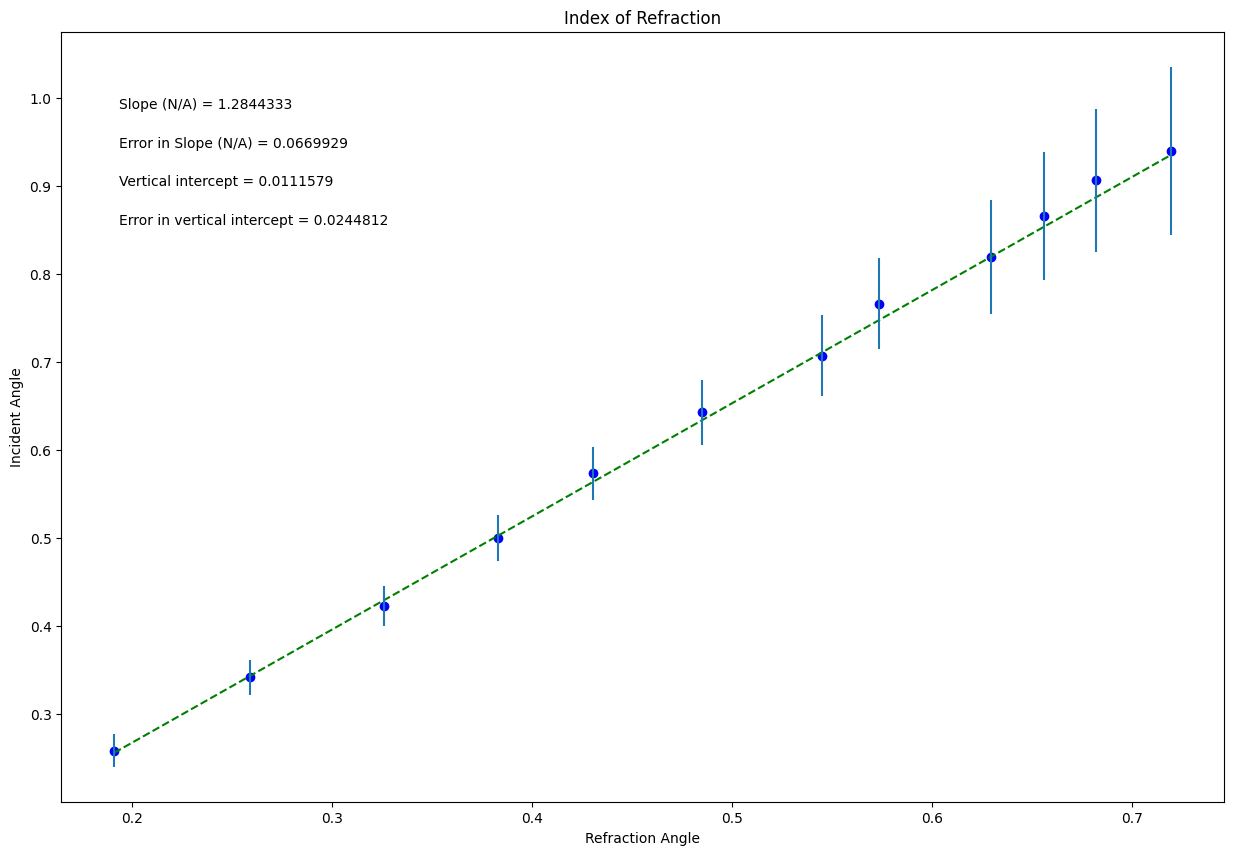

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#-----------------------------------------------------------------------#
#----------UPDATE THIS SECTION!!!----------

#DATA TO BE PLOTTED
#UPDATE THE VARIABLE NAMES & NUMBERS (LEAVE BRACKETS/PARENTHESES AS IS)
#variable names should start with a letter and must contain only letters, numbers, and underscores


Refraction_Angle = np.array([0.1908089954,	0.2588190451,	0.3255681545,	0.3826834324,	0.4305110968,	0.4848096202,	0.544639035,	0.5735764364,	0.629320391,	0.656059029,	0.6819983601,	0.7193398003])

Incident_Angle = np.array([0.2588190451,	0.3420201433,	0.4226182617,	0.5,	0.5735764364,	0.6427876097,	0.7071067812,	0.7660444431,	0.8191520443,	0.8660254038,	0.906307787,	0.9396926208])

err_Refracted_Angle = np.array([0.01833701227,0.01987618324,0.02259364082,0.02619485836,0.03036105023,0.03666569992,0.04602312627,0.05164934335,0.06497113602,0.07273310287,0.08127123875,0.09559845918])



#Re-assign variables as x, y, dy so that the remaining plotting code may remain generic
#UPDATE VARIABLE NAMES (ON RHS OF EACH EQUAL SIGN) TO MATCH VARIABLE NAMES FOR DATA ABOVE
x = Refraction_Angle             #this should be the array you want to plot on the x axis
y = Incident_Angle             #this should be the array you want to plot on the y axis
dy = err_Refracted_Angle        #this should be your error in y array


#UPDATE EACH OF THESE 4 STRINGS FOR YOUR PLOT LABELS AS YOU WANT THEM TO APPEAR

plot_title= 'Index of Refraction'
x_label= 'Refraction Angle'
y_label= 'Incident Angle'
slope_units= 'N/A'

#UPDATE ANNOTATION PLACEMENT SO IT'S OUT OF WAY OF PLOTTED DATA AND BEST FIT LINE
#integer from 1 to 4, top R corner is 1 (counter-clockwise from there)

annotation_placement=2


#-----------------------------------------------------------------------#
#-----DON'T NEED TO CHANGE ANYTHING BEYOND THIS POINT!!!----- # Removed %matplotlib inline

# Find the intercept and slope, b and m, from Python's polynomial fitting function
if np.all(dy == 0): # Check if all error values are zero
    b,m=np.polynomial.polynomial.polyfit(x,y,1) # Fit without weights (equal weights)
    D, dm, db, N = np.nan, np.nan, np.nan, np.nan # Errors cannot be calculated if no error data
else:
    weights = 1/dy**2 # Calculate weights as inverse of square of errors
    b,m=np.polynomial.polynomial.polyfit(x,y,1,w=weights) # Fit with weights

    # Calculate the error in slope and intercept
    def Delta(x, dy):
        # Use weights (1/dy**2) for error calculation as implied by the original formulas
        w = 1/dy**2
        D_val = (sum(w))*(sum(x**2*w))-(sum(x*w))**2
        return D_val

    D=Delta(x, dy)

    dm = np.sqrt(1/D*sum(1/dy**2)) # error in slope
    db = np.sqrt(1/D*sum(x**2/dy**2)) # error in intercept

    # Calculate the "goodness of fit" using linear least squares fitting
    def LLSFD2(x,y,dy):
        N_val = sum(((y-b-m*x)/dy)**2)
        return N_val

    N = LLSFD2(x,y,dy)


#Write the equation for the best fit line based on the slope and intercept
fit = b+m*x

#assign annotation positions based on annotation_placement value
if annotation_placement==2 or annotation_placement==3:
    xpos=0.05
elif annotation_placement==1 or annotation_placement==4:
    xpos=0.75

if annotation_placement==1 or annotation_placement==2:
    ypos=[.9,.85,.8,.75]
elif annotation_placement==3 or annotation_placement==4:
    ypos=[.2,.15,.1,.05]

#-----------------------------------------------------------------------#
#Don't need to change anything in this section!

#Plot data on graph. Plot error bars and place values for slope,
#error in slope, and vertical intercept (plus error) on the plot using "annotate"

plt.figure(figsize=(15,10))

plt.plot(x, fit, color='green', linestyle='--')
plt.scatter(x, y, color='blue', marker='o')

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(plot_title)

# Only plot error bars if dy is not all zeros
if np.any(dy != 0):
    plt.errorbar(x, y, yerr=dy, xerr=None, fmt="none") #don't need to plot x error bars

plt.annotate('Slope ({}) = {value:.{digits}f}'.format(slope_units,value=m, digits=7),
             (xpos, ypos[0]), xycoords='axes fraction')

if not np.isnan(dm):
    plt.annotate('Error in Slope ({}) = {value:.{digits}f}'.format(slope_units,value=dm, digits=7),
                 (xpos, ypos[1]), xycoords='axes fraction')
else:
    plt.annotate('Error in Slope ({}): No error data provided'.format(slope_units),
                 (xpos, ypos[1]), xycoords='axes fraction')

plt.annotate('Vertical intercept = {value:.{digits}f}'.format(value=b, digits=7),
             (xpos, ypos[2]), xycoords='axes fraction')

if not np.isnan(db):
    plt.annotate('Error in vertical intercept = {value:.{digits}f}'.format(value=db, digits=7),
                 (xpos, ypos[3]), xycoords='axes fraction')
else:
    plt.annotate('Error in vertical intercept: No error data provided',
                 (xpos, ypos[3]), xycoords='axes fraction')

plt.show()